In [1]:
%matplotlib widget

import os
import cv2
import numpy as np
import numpy as np
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import subplot
from matplotlib.colors import LogNorm
from matplotlib.widgets import SpanSelector
from tqdm.auto import tqdm
from scipy.optimize import leastsq

# Set environment variables for OpenCV
os.environ['OPENCV_LOG_LEVEL'] = 'FATAL'
os.environ['OPENCV_FFMPEG_LOGLEVEL'] = "-8"

all_results = {} # This will store tau, MSD, G', G'' for each system

In [17]:
system_name = "20% Pluronics" # Change this for each system
file_path = "/Volumes/MyMedia SSD/pluronics_selected/500interval-20_2026-03-04-175514-0000_ISF_corrected.npz"

data = np.load(file_path)
ISF, qs, dts = data['ISF'], data['qs'], data['dts']
tmax = -1 # Or your preferred value
# --- REPLACEMENT FOR CELL 40: Bounded A & B Optimization ---
import numpy as np
from scipy.optimize import least_squares

params = np.zeros((ISF.shape[-1], 3))
matrixfit = np.zeros(ISF[:tmax].T.shape)

# DDM Model: A*(1 - exp(-t/tau_c)) + B
def model_ddm(p, dts):
    return p[0] * (1.0 - np.exp(-dts / p[2])) + p[1]

# Residual function in log-space to handle orders of magnitude gracefully
def residual(p, dts, y):
    return np.log(np.maximum(model_ddm(p, dts), 1e-10)) - np.log(np.maximum(y, 1e-10))

for iq, ddm in enumerate(ISF[:tmax].T):
    # Smart initial guesses
    B_guess = np.min(ddm[:3]) if len(ddm) > 3 else ddm.min()
    A_guess = np.ptp(ddm)
    tc_guess = 1.0
    
    # Fit using least_squares with strict positivity bounds [A, B, tau_c]
    res = least_squares(
        residual, 
        x0=[max(A_guess, 1e-6), max(B_guess, 1e-6), tc_guess], 
        bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
        args=(dts[:tmax], ddm)
    )
    
    params[iq] = res.x
    matrixfit[iq] = model_ddm(res.x, dts[:tmax])

print("A, B, and tau_c optimization complete with strict positive bounds.")

A, B, and tau_c optimization complete with strict positive bounds.


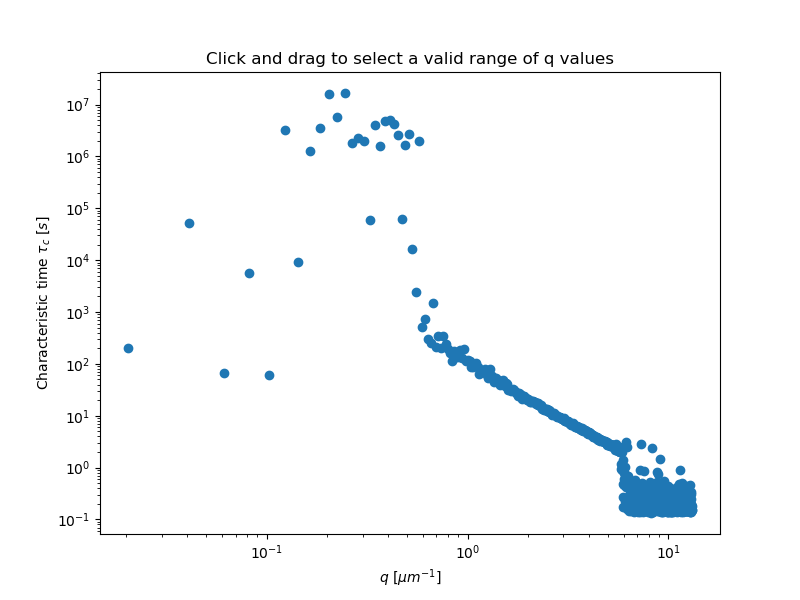

In [18]:
def onselect(xmin, xmax):
    global iqmin, iqmax
    iqmin= np.searchsorted(qs, xmin)
    iqmax = np.searchsorted(qs, xmax)
    print(f"Selected range: {qs[iqmin]:.2f} to {qs[iqmax]:.2f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(qs, params[:, 2], 'o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$q\ [\mu m^{-1}$]')
ax.set_ylabel(r'Characteristic time $\tau_c\ [s]$')
ax.set_title('Click and drag to select a valid range of q values')

span = SpanSelector(ax, onselect, 'horizontal', useblit=True, interactive=True, props=dict(alpha=0.5, facecolor='red'))
plt.show()

In [19]:
# Essential definitions for the next selection step
tau_all = dts[:tmax] # <--- FIX: This defines tau_all for the current system
q_sel = qs[iqmin:iqmax]
Aq, Bq = params[iqmin:iqmax, 0], params[iqmin:iqmax, 1]

f_qtau = np.clip(1.0 - (ISF[:tmax, iqmin:iqmax] - Bq) / Aq, 1e-10, 1.0)
MSD_qtau = -(4.0 / (q_sel[None, :]**2)) * np.log(f_qtau)

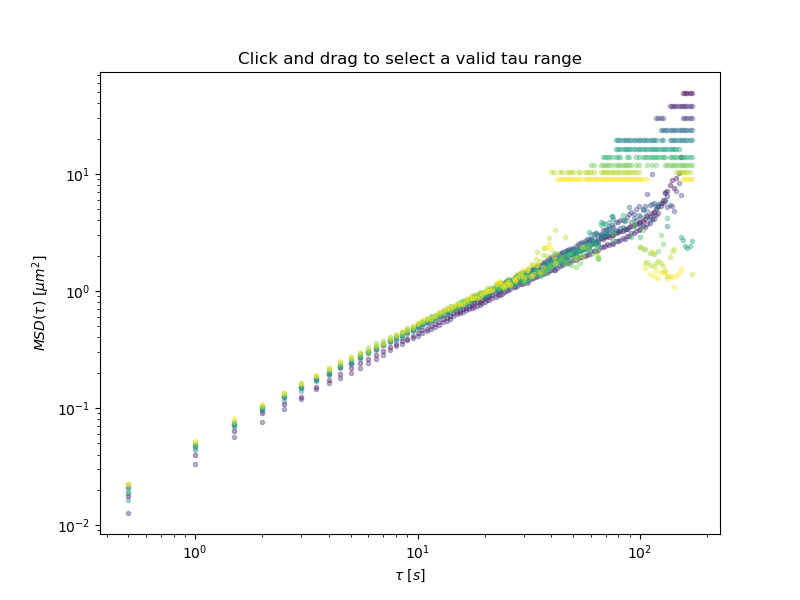

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector

# Default selection: full tau range (override by dragging)
itmin, itmax = 0, len(tau_all)

def onselect_tau(xmin, xmax):
    global itmin, itmax
    xmin, xmax = sorted((xmin, xmax))
    itmin = int(np.searchsorted(tau_all, xmin, side='left'))
    itmax = int(np.searchsorted(tau_all, xmax, side='right'))
    itmin = max(0, min(itmin, len(tau_all) - 1))
    itmax = max(itmin + 1, min(itmax, len(tau_all)))
    print(f"Selected tau range: {tau_all[itmin]:.3g} to {tau_all[itmax-1]:.3g} s (indices {itmin}:{itmax})")

# Plot a subset of q-modes to help choose a tau-window where MSD collapses
n_show = 10
idx_rel = np.linspace(0, len(q_sel) - 1, n_show, dtype=int)
idx_rel = np.unique(idx_rel)
colors = plt.cm.viridis(np.linspace(0, 1, len(idx_rel)))

fig, ax = plt.subplots(figsize=(8, 6))
for c, j in zip(colors, idx_rel):
    ax.plot(tau_all, MSD_qtau[:, j], '.', color=c, alpha=0.35)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\tau\ [s]$')
ax.set_ylabel(r'$MSD(\tau)\ [\mu m^2]$')
ax.set_title('Click and drag to select a valid tau range')
span_tau = SpanSelector(ax, onselect_tau, 'horizontal', useblit=True, interactive=True, props=dict(alpha=0.3, facecolor='red'))
plt.show()

In [21]:
tau_final = tau_all[itmin:itmax]
msd_final = np.nanmean(MSD_qtau[itmin:itmax, :], axis=1)

# Run GSER (using your Cell 60 replacement logic)
# --- REPLACEMENT FOR CELL 60: Publishable GSER Pipeline with Terminal Fits ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

# --- 1. Physical Constants & Experimental Parameters ---
kb = 1.380649e-23      
T_kelvin = 23.0 + 273.15 
radius_m = 150e-9      # *** CHANGE TO YOUR ACTUAL TRACER RADIUS (meters) ***

# --- 2. Data Prep & Cleaning ---
valid = np.isfinite(tau_final) & (tau_final > 0) & np.isfinite(msd_final) & (msd_final > 0)
tau_v = tau_final[valid]
msd_v = msd_final[valid] * 1e-12 # Convert from um^2 (DDM standard) to m^2

# Ensure strictly increasing for interpolation
order_tau = np.argsort(tau_v)
tau_v = tau_v[order_tau]
msd_v = msd_v[order_tau]

log_tau_raw = np.log(tau_v)
log_msd_raw = np.log(msd_v)

# --- 3. Interpolation onto a UNIFORM log grid ---
num_points = 100
log_tau_uniform = np.linspace(log_tau_raw.min(), log_tau_raw.max(), num_points)

interpolator = interp1d(log_tau_raw, log_msd_raw, kind='linear')
log_msd_uniform = interpolator(log_tau_uniform)

# --- 4. Smoothing and Derivative ---
win = 5
poly = 2
dlogtau = log_tau_uniform[1] - log_tau_uniform[0] 

log_msd_smooth = savgol_filter(log_msd_uniform, window_length=win, polyorder=poly)
alpha = savgol_filter(log_msd_smooth, window_length=win, polyorder=1, deriv=1, delta=dlogtau)

# Soft boundaries to prevent math crashes, but preserve actual liquid/solid physics
alpha = np.clip(alpha, 0.001, 0.999)

# --- 5. Transform back to physical variables ---
omega = 1.0 / np.exp(log_tau_uniform)
msd_smooth = np.exp(log_msd_smooth)

# GSER Calculation
prefactor = (kb * T_kelvin) / (np.pi * radius_m * msd_smooth * gamma(1.0 + alpha))
Gp = prefactor * np.cos(np.pi * alpha / 2.0)
Gpp = prefactor * np.sin(np.pi * alpha / 2.0)

# Sort by frequency for plotting & fitting
order = np.argsort(omega)
omega = omega[order]
Gp = Gp[order]
Gpp = Gpp[order]


all_results[system_name] = {
    'tau': tau_final, 
    'msd': msd_final,
    'omega': omega, 
    'gp': Gp, 
    'gpp': Gpp
}
print(f"Stored {system_name}. Now update the file_path for the next system.")

Stored 20% Pluronics. Now update the file_path for the next system.


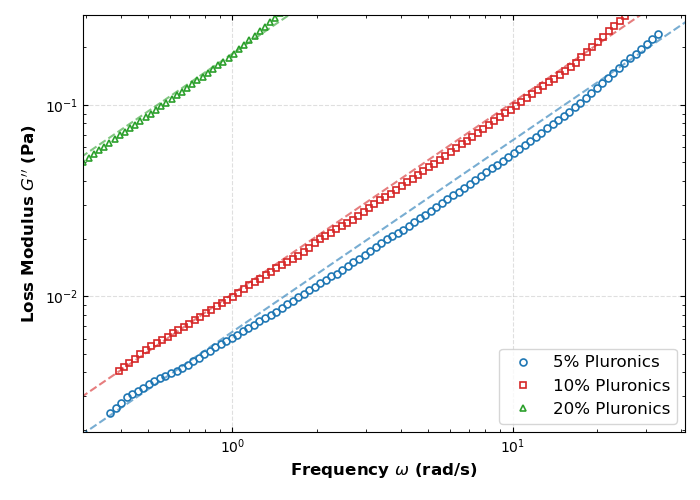

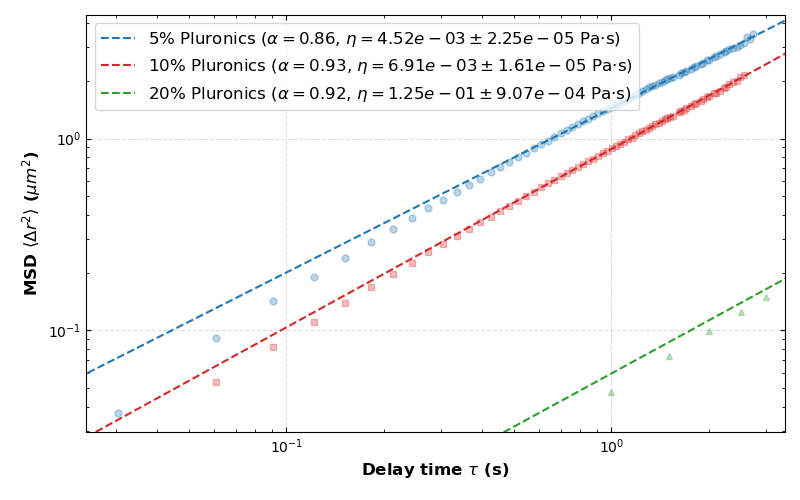

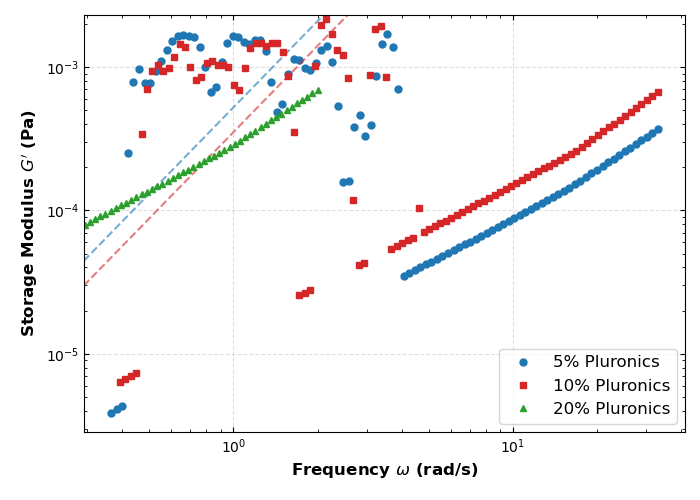

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1. PHYSICAL CONSTANTS (Required for Stokes-Einstein) ---
kb = 1.380649e-23      
T_kelvin = 23.0 + 273.15 
radius_m = 150e-9  # *** Verify this matches your tracer radius! ***

# --- 2. EXPANDED PALETTES ---
colors = [
    '#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', 
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
]
markers = ['o', 's', '^', 'D', 'p', 'h', 'v', '8', '<', '>']

def power_law(t, a, alpha):
    return a * (t**alpha)

def linear_model(t, m):
    """Purely viscous terminal diffusion model: MSD = m * tau"""
    return m * t

# --- 3. INITIALIZE THREE SEPARATE FIGURES ---
fig1, ax1 = plt.subplots(figsize=(8, 5), dpi=100)
fig2, ax2 = plt.subplots(figsize=(7, 5), dpi=100)
fig3, ax3 = plt.subplots(figsize=(7, 5), dpi=100)

for i, (name, res) in enumerate(all_results.items()):
    c = colors[i % len(colors)]
    m_marker = markers[i % len(markers)]
    
    # ==========================================
    # FIGURE 1: MSD vs Tau & Viscosity Calc
    # ==========================================
    valid_msd = np.isfinite(res['tau']) & np.isfinite(res['msd']) & (res['tau'] > 0) & (res['msd'] > 0)
    t_fit = res['tau'][valid_msd]
    msd_fit = res['msd'][valid_msd]
    
    # Plot raw MSD data
    ax1.loglog(t_fit, msd_fit, marker=m_marker, color=c, alpha=0.3, markersize=5, linestyle='None', label='_nolegend_')
    xlim1, ylim1 = ax1.get_xlim(), ax1.get_ylim()
    
    try:
        # A. Fit the full curve for the dashed visual line and alpha value
        popt_pow, _ = curve_fit(power_law, t_fit, msd_fit, p0=[msd_fit[0], 1.0], maxfev=10000)
        alpha_val = popt_pow[1]
        
        # B. Calculate Viscosity using ONLY the terminal regime (longest 33% of tau)
        n_tail = max(4, int(0.33 * len(t_fit)))
        t_tail = t_fit[-n_tail:]
        msd_tail = msd_fit[-n_tail:]
        
        popt_lin, pcov_lin = curve_fit(linear_model, t_tail, msd_tail)
        
        # Convert slope from um^2/s to m^2/s
        m_slope = popt_lin[0] * 1e-12 
        m_err = np.sqrt(np.diag(pcov_lin))[0] * 1e-12
        
        # Calculate Viscosity (Assuming 2D MSD: MSD = 4*D*tau)
        C_factor = (2.0 * kb * T_kelvin) / (3.0 * np.pi * radius_m)
        eta = C_factor / m_slope
        
        # Propagate Error: delta_eta = eta * (delta_m / m)
        eta_err = eta * (m_err / m_slope)
        
        # Format the legend string
        legend_str = rf"{name} ($\alpha={alpha_val:.2f}$, $\eta={eta:.2e} \pm {eta_err:.2e}$ Pa$\cdot$s)"
        
        # Draw the full-spanning dashed line
        t_line = np.logspace(np.log10(xlim1[0]/10), np.log10(xlim1[1]*10), 100)
        ax1.loglog(t_line, power_law(t_line, *popt_pow), linestyle='--', color=c, linewidth=1.5, label=legend_str)
        
    except Exception:
        pass
        
    ax1.set_xlim(xlim1)
    ax1.set_ylim(ylim1)

    # ==========================================
    # FIGURES 2 & 3: G' and G'' 
    # ==========================================
    if 'omega' in res and len(res['omega']) > 0:
        valid_g = (np.isfinite(res['omega']) & np.isfinite(res['gp']) & np.isfinite(res['gpp']) & 
                   (res['omega'] > 0) & (res['gp'] > 0) & (res['gpp'] > 0))
        omega_v = res['omega'][valid_g]
        gp_v = res['gp'][valid_g]
        gpp_v = res['gpp'][valid_g]
        
        if len(omega_v) > 5:
            sort_idx = np.argsort(omega_v)
            omega_v, gp_v, gpp_v = omega_v[sort_idx], gp_v[sort_idx], gpp_v[sort_idx]
            
            # --- FIGURE 2: G' (Fit first 50% with exact omega^2) ---
            ax2.loglog(omega_v, gp_v, marker=m_marker, color=c, markersize=5, linestyle='None', label=f"{name}")
            xlim2, ylim2 = ax2.get_xlim(), ax2.get_ylim()
            
            n_low_gp = max(3, int(0.50 * len(omega_v)))
            Kp = np.exp(np.mean(np.log(gp_v[:n_low_gp]) - 2.0 * np.log(omega_v[:n_low_gp])))
            
            omega_line2 = np.logspace(np.log10(xlim2[0]/10), np.log10(xlim2[1]*10), 100)
            ax2.loglog(omega_line2, Kp * omega_line2**2.0, linestyle='--', color=c, alpha=0.6)
            
            ax2.set_xlim(xlim2)
            ax2.set_ylim(ylim2)
            
            # --- FIGURE 3: G'' (Fit first 25% with exact omega^1) ---
            ax3.loglog(omega_v, gpp_v, marker=m_marker, markerfacecolor='none', markeredgecolor=c, 
                       markeredgewidth=1.2, markersize=5, linestyle='None', label=f"{name}")
            xlim3, ylim3 = ax3.get_xlim(), ax3.get_ylim()
            
            n_low_gpp = max(3, int(0.25 * len(omega_v)))
            Kpp = np.exp(np.mean(np.log(gpp_v[:n_low_gpp]) - 1.0 * np.log(omega_v[:n_low_gpp])))
            
            omega_line3 = np.logspace(np.log10(xlim3[0]/10), np.log10(xlim3[1]*10), 100)
            ax3.loglog(omega_line3, Kpp * omega_line3**1.0, linestyle='--', color=c, alpha=0.6)
            
            ax3.set_xlim(xlim3)
            ax3.set_ylim(ylim3)

# --- 4. REFINED STYLING FOR EACH FIGURE ---

# FIGURE 1 Styling (Slightly wider to accommodate the new math in the legend)
ax1.set_xlabel(r'Delay time $\tau$ (s)', fontsize=12, fontweight='bold')
ax1.set_ylabel(r'MSD $\langle \Delta r^2 \rangle$ ($\mu m^2$)', fontsize=12, fontweight='bold')
ax1.legend(frameon=True, loc='best', fontsize=12, edgecolor='0.8')
fig1.tight_layout()

# FIGURE 2 Styling
ax2.set_xlabel(r'Frequency $\omega$ (rad/s)', fontsize=12, fontweight='bold')
ax2.set_ylabel(r"Storage Modulus $G'$ (Pa)", fontsize=12, fontweight='bold')
ax2.legend(frameon=True, loc='best', fontsize=12, edgecolor='0.8')
fig2.tight_layout()

# FIGURE 3 Styling
ax3.set_xlabel(r'Frequency $\omega$ (rad/s)', fontsize=12, fontweight='bold')
ax3.set_ylabel(r"Loss Modulus $G''$ (Pa)", fontsize=12, fontweight='bold')
ax3.legend(frameon=True, loc='best', fontsize=12, edgecolor='0.8')
fig3.tight_layout()

# Global Plot Refinements
for ax in [ax1, ax2, ax3]:
    ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=10)
    ax.grid(True, which='major', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

fig1.savefig('pluronics_msd.png', dpi=300)
fig2.savefig('pluronics_gprime.png', dpi=300)
fig3.savefig('pluronics_gpp.png', dpi=300)

plt.show()